# Heart Diseease Dataset



Anggota Kelompok:
- Benedictus Ryu Gubnawan - 5054510001
- Muhammad Fasya Atthaya Rosyada - 5054510006
- Pranaja Adyatama Budiman - 5054510009

# Dataset Overview

| Fitur      | Penjelasan                                                                                                                                                      |
| ---------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `age`      | Usia pasien dalam tahun.                                                                                                                                        |
| `sex`      | Jenis kelamin pasien (`1` = laki-laki, `0` = perempuan).                                                                                                        |
| `cp`       | Tipe nyeri dada (*chest pain type*): `0` = asymptomatic, `1` = atypical angina, `2` = non-anginal pain, `3` = typical angina.                                   |
| `trestbps` | Tekanan darah saat istirahat (*resting blood pressure*) dalam mmHg.                                                                                             |
| `chol`     | Kadar kolesterol serum dalam mg/dL.                                                                                                                             |
| `fbs`      | Gula darah puasa (*fasting blood sugar*) > 120 mg/dL (`1` = ya, `0` = tidak).                                                                                   |
| `restecg`  | Hasil elektrokardiografi saat istirahat (*resting ECG*): `0` = normal, `1` = memiliki abnormalitas gelombang ST-T, `2` = menunjukkan hipertrofi ventrikel kiri. |
| `thalach`  | Denyut jantung maksimum yang dicapai (*maximum heart rate achieved*).                                                                                           |
| `exang`    | Angina yang dipicu oleh olahraga (*exercise induced angina*) (`1` = ya, `0` = tidak).                                                                           |
| `oldpeak`  | Depresi segmen ST akibat olahraga dibanding kondisi istirahat. Merupakan indikator tingkat iskemia jantung.                                                     |
| `slope`    | Kemiringan segmen ST saat puncak olahraga: `0` = downsloping, `1` = flat, `2` = upsloping.                                                                      |
| `ca`       | Jumlah pembuluh darah utama (*major vessels*) yang terlihat melalui fluoroskopi, bernilai 0-4.                                                                  |
| `thal`     | Hasil pemeriksaan Thalassemia: `0` = null/unknown, `1` = fixed defect, `2` = normal, `3` = reversible defect.                                                   |
| `target`   | Label target penyakit jantung (`1` = memiliki penyakit jantung, `0` = tidak memiliki penyakit jantung).                                                         |


# Setting Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from dataclasses import dataclass
import warnings
warnings.filterwarnings("ignore")

@dataclass
class Config:
    root_dir: Path = Path(os.getcwd()).parent
    data_dir: Path = root_dir / "data"
    seed: int = 3407 # bcs 3407 is all you need (https://arxiv.org/abs/2109.08203)
    target: str = "target"

def set_viz_theme():
    sns.set_theme(style="whitegrid")
    plt.rcParams["figure.figsize"] = (10, 6)
    plt.rcParams["axes.titlesize"] = 16
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["xtick.labelsize"] = 12
    plt.rcParams["ytick.labelsize"] = 12

cfg = Config()
set_viz_theme()

print(f"Root directory: {cfg.root_dir}")
print(f"Data directory: {cfg.data_dir}")


Root directory: /home/ryz/data/collage/sem3/datmin/Repo/week 3/makalah
Data directory: /home/ryz/data/collage/sem3/datmin/Repo/week 3/makalah/data


# Prepare Dataset

In [2]:
df = pd.read_csv(cfg.data_dir / "heart_disease_dataset.csv")

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
display(df.head())
display(df.info())

Data shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None

Dari tipe data dan penjelasan masing-masing fitur dapat terlihat apabila, atribut data dari fitur tersebut sebagai berikut,

| Fitur      | Atribut Data                |
| ---------- | --------------------------- |
| `age`      | Numerik Kontinu             |
| `sex`      | Kategorikal Nominal (Biner) |
| `cp`       | Kategorikal Nominal         |
| `trestbps` | Numerik Kontinu             |
| `chol`     | Numerik Kontinu             |
| `fbs`      | Kategorikal Nominal (Biner) |
| `restecg`  | Kategorikal Nominal         |
| `thalach`  | Numerik Kontinu             |
| `exang`    | Kategorikal Nominal (Biner) |
| `oldpeak`  | Numerik Kontinu             |
| `slope`    | Kategorikal Ordinal         |
| `ca`       | Numerik Diskrit             |
| `thal`     | Kategorikal Nominal         |
| `target`   | Kategorikal Nominal (Biner) |


disini ada beberapa tipe data yang tidak sesuai dengan `domain knowledge` seperti, `Kategorikal Nominal` yang seharusnya adalah object

In [3]:
nominal_cat = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

for col in nominal_cat:
    df[col] = df[col].astype(object)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   object 
 2   cp        1025 non-null   object 
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   object 
 6   restecg   1025 non-null   object 
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   object 
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   object 
 11  ca        1025 non-null   object 
 12  thal      1025 non-null   object 
 13  target    1025 non-null   object 
dtypes: float64(1), int64(4), object(9)
memory usage: 112.2+ KB


# Exploratory Data Analysis (EDA)

In [4]:
cols = df.columns.tolist()
n_col = len(cols)
n_row = df.shape[0]

print(f"Number of columns: {n_col}")
print(f"Number of rows: {n_row}")

Number of columns: 14
Number of rows: 1025


## Univariate Analysis

Analisa EDA terhadap fitur secara independen tanpa melibatkan fitur lainnya

In [5]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(exclude="object").columns.tolist()

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


### Check Duplicate

In [6]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = df.duplicated().mean() * 100

print(f"Duplicate rows       : {duplicate_count}")
print(f"Duplicate percentage : {duplicate_percentage:.2f}%")

df = df.drop_duplicates()

Duplicate rows       : 723
Duplicate percentage : 70.54%


Ternyata disini ada sekiatr 70% duplicate values. Disini bisa jadi terjadi kesalahan dalam pencatatan seperti, `double write`

### Missing Values Analysis

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


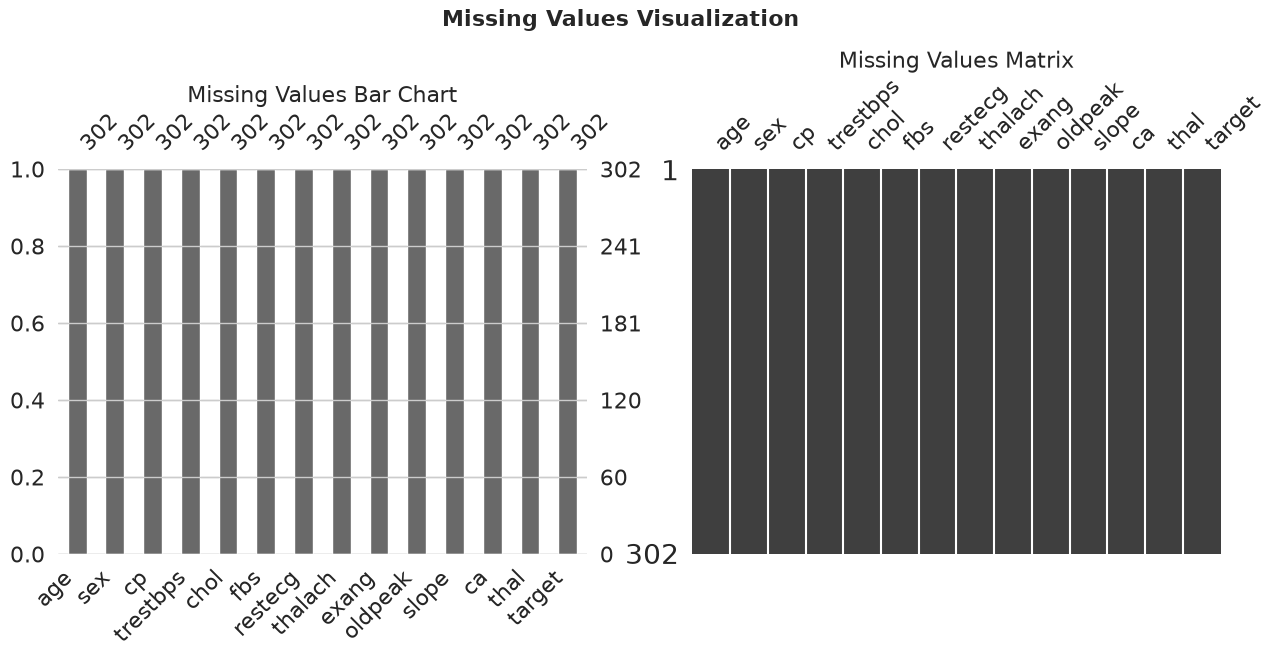

In [7]:
import missingno as msno

print(f"Missing values in each column:\n{df.isnull().sum()}")

fig,ax = plt.subplots(1,2,figsize=(15,5))
plt.suptitle("Missing Values Visualization", fontsize=16, fontweight='bold', y=1.2)

ax[0].set_title("Missing Values Bar Chart")
msno.bar(df, ax=ax[0])

ax[1].set_title("Missing Values Matrix")
msno.matrix(df, ax=ax[1])
plt.show()

tidak ada missing value pada dataset ini

### Cardinality Distribution

Menghitung distribusi kardinalitas fitur kategorikal

Text(0, 0.5, 'Categorical Features')

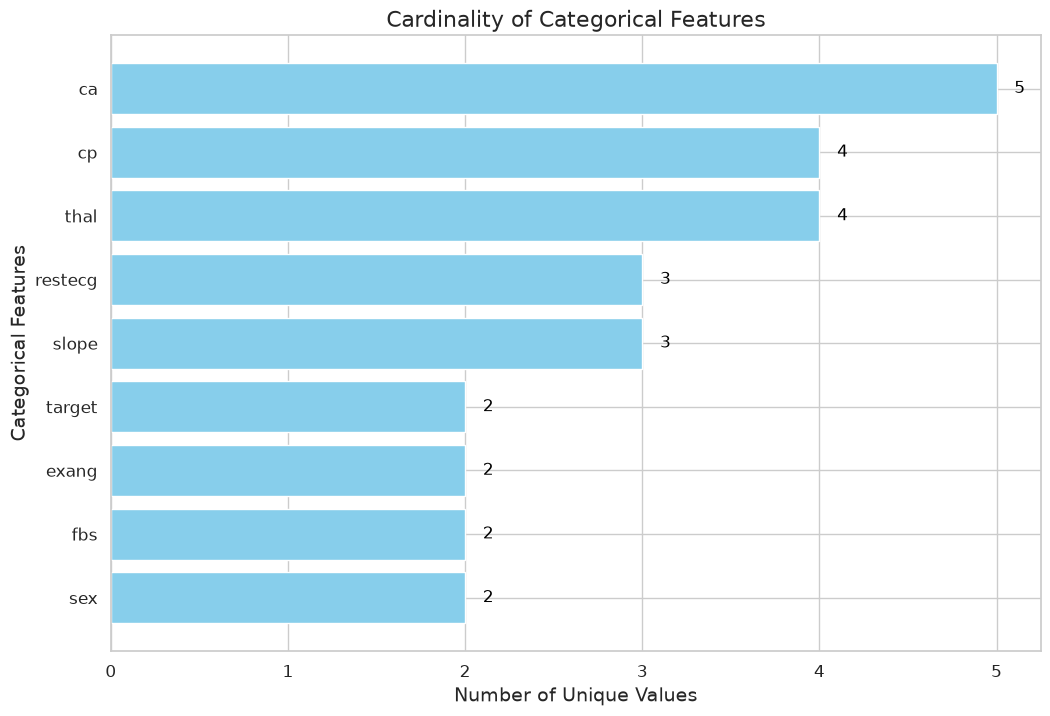

In [8]:
plt.figure(figsize=(12, 8))
plt.title("Cardinality of Categorical Features")
cardinality = df[cat_cols].nunique().sort_values(ascending=True)
plt.barh(cardinality.index, cardinality.values, color="skyblue")
for i, v in enumerate(cardinality.values):
    plt.text(v + 0.1, i, str(v), color='black', va='center')

plt.xlabel("Number of Unique Values")
plt.ylabel("Categorical Features")

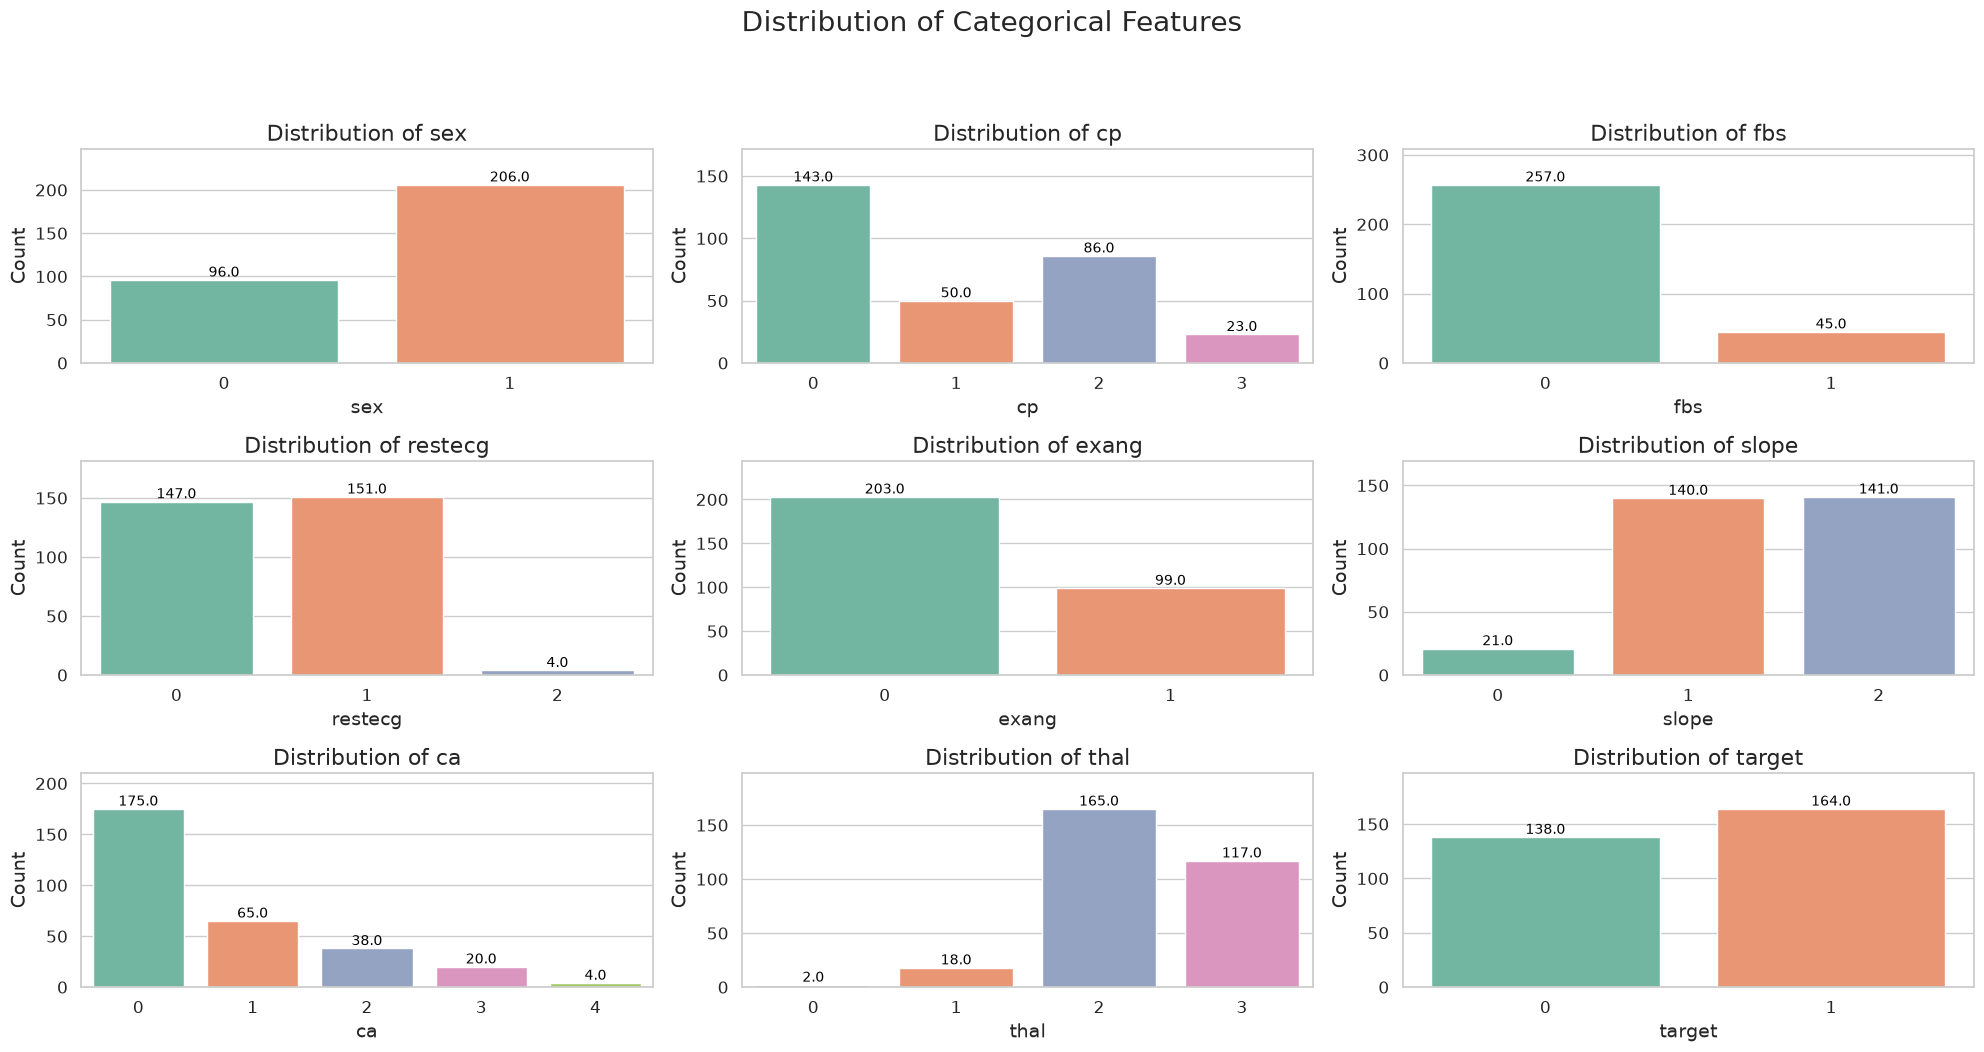

In [9]:
fig,ax = plt.subplots(3,3, figsize=(20, 10))
plt.suptitle("Distribution of Categorical Features", fontsize=20, y=1.05)
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=ax[i//3, i%3], palette="Set2")
    ax[i//3, i%3].set_title(f"Distribution of {col}")
    ax[i//3, i%3].set_xlabel(col)
    ax[i//3, i%3].set_ylabel("Count")

    ax[i//3, i%3].set_ylim(0, df[col].value_counts().max()*1.2)
    for p in ax[i//3, i%3].patches:
        ax[i//3, i%3].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()

Berdasarkan hasil plot diatas dapat terlihat apabila, distributsi dari categorical features tersbeut beberapa mengalami imbalanced

### Numerical Distribution

In [10]:
df.describe()

,age,trestbps,chol,thalach,oldpeak
count,302.00000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046
std,9.04797,17.563394,51.753489,22.903527,1.161452
min,29.00000,94.000000,126.000000,71.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000
75%,61.00000,140.000000,274.750000,166.000000,1.600000
max,77.00000,200.000000,564.000000,202.000000,6.200000


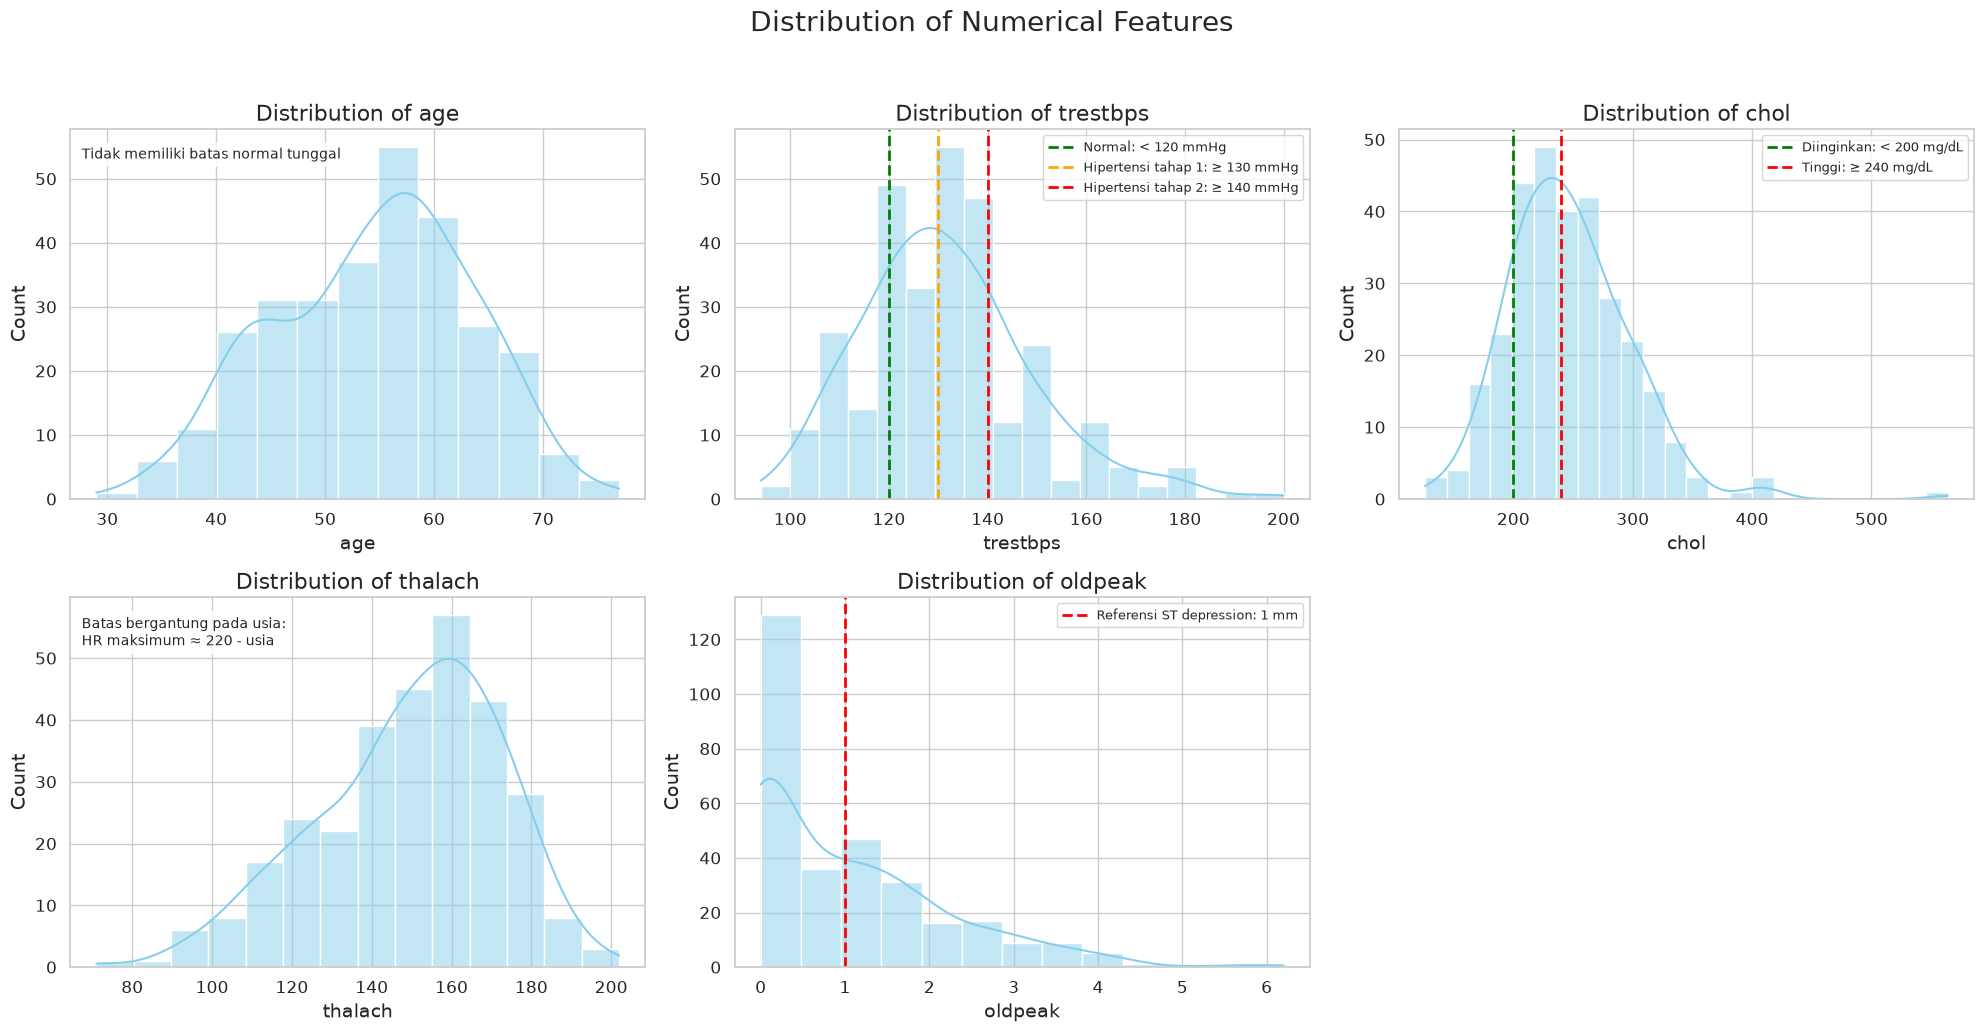

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# mecial ref
medical_thresholds = {
    "trestbps": [
        {
            "value": 120,
            "label": "Normal: < 120 mmHg",
            "color": "green",
            "linestyle": "--"
        },
        {
            "value": 130,
            "label": "Hipertensi tahap 1: ≥ 130 mmHg",
            "color": "orange",
            "linestyle": "--"
        },
        {
            "value": 140,
            "label": "Hipertensi tahap 2: ≥ 140 mmHg",
            "color": "red",
            "linestyle": "--"
        }
    ],
    "chol": [
        {
            "value": 200,
            "label": "Diinginkan: < 200 mg/dL",
            "color": "green",
            "linestyle": "--"
        },
        {
            "value": 240,
            "label": "Tinggi: ≥ 240 mg/dL",
            "color": "red",
            "linestyle": "--"
        }
    ],
    "oldpeak": [
        {
            "value": 1.0,
            "label": "Referensi ST depression: 1 mm",
            "color": "red",
            "linestyle": "--"
        }
    ]
}

fig, ax = plt.subplots(2, 3, figsize=(20, 10))
ax = ax.flatten()

num_plots = len(num_cols)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=20,
    y=1.03
)

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax[i],
        color="skyblue"
    )

    ax[i].set_title(f"Distribution of {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Count")

    if col in medical_thresholds:
        for threshold in medical_thresholds[col]:
            ax[i].axvline(
                x=threshold["value"],
                color=threshold["color"],
                linestyle=threshold["linestyle"],
                linewidth=2,
                label=threshold["label"]
            )

        ax[i].legend(
            fontsize=9,
            loc="upper right",
            frameon=True
        )

    elif col == "age":
        ax[i].text(
            0.02,
            0.95,
            "Tidak memiliki batas normal tunggal",
            transform=ax[i].transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox={
                "boxstyle": "round",
                "facecolor": "white",
                "alpha": 0.8
            }
        )

    elif col == "thalach":
        ax[i].text(
            0.02,
            0.95,
            "Batas bergantung pada usia:\nHR maksimum ≈ 220 - usia",
            transform=ax[i].transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox={
                "boxstyle": "round",
                "facecolor": "white",
                "alpha": 0.8
            }
        )

for a in ax[num_plots:]:
    a.remove()

plt.tight_layout()
plt.show()

sepertinya disini ada beberapa data yang mengalami skew. Ada hal menarik dimana sepertinya, hasil skew bisa terjadi karena ada beberapa fitur yang ketergantungan sama fitur lainnya seperti, pada thalach. Jika melihat batas medisnya, hasil skew seperti ini cukup wajar karena tidak smeua orang berada pada kondisi `sehat`

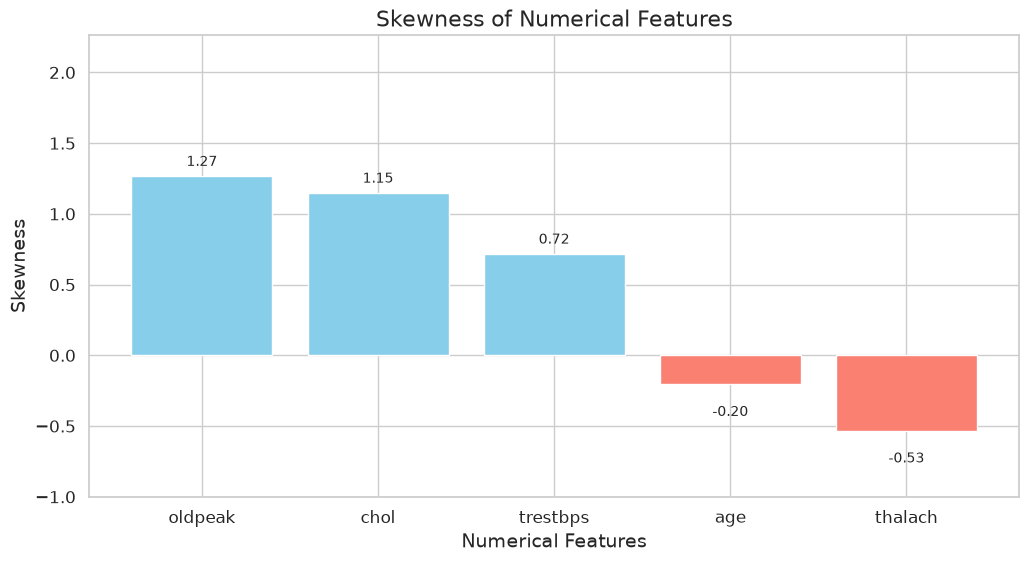

In [12]:
skewness = df[num_cols].skew().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
color = ["skyblue" if val >= 0 else "salmon" for val in skewness.values]

plt.bar(skewness.index, skewness.values, color=color)
plt.title("Skewness of Numerical Features")
plt.xlabel("Numerical Features")
plt.ylabel("Skewness")
plt.ylim(-1, max(skewness.values) + 1)

for i, v in enumerate(skewness.values):
    plt.text(i, v + 0.05 if v >= 0 else v - 0.15, f"{v:.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)

Berdasarkan kurtosis nilai yang diberikan cenderung `moderate skew` yang berkisaran anatara +1 untuk `oldpeak` dan `chol`. Tetapi, karena disini berkaitan dengan ritme jantung dan juga kolestrol sebenarnya masih masuk akal apabila, terjadi skew karena tidak semua orang berada pada kondisi normal

## Multivariate Analysis

### Distribusi Dari Prediksi Maksimum Detak Jantung Berdasarkan Usia

$$
 \%HR_{max} = \frac{thalach}{220-age} * 100\%
$$

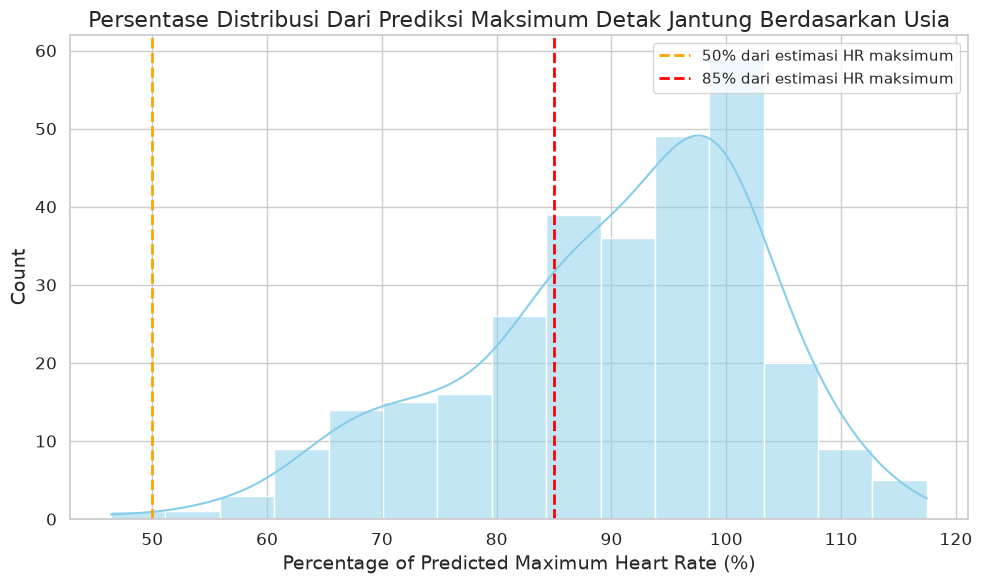

In [13]:
df_plot = df.copy()

df_plot["predicted_max_hr"] = 220 - df_plot["age"]

df_plot["thalach_pct_max"] = (
    df_plot["thalach"] / df_plot["predicted_max_hr"]
) * 100

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_plot,
    x="thalach_pct_max",
    kde=True,
    color="skyblue"
)

plt.axvline(
    50,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="50% dari estimasi HR maksimum"
)

plt.axvline(
    85,
    color="red",
    linestyle="--",
    linewidth=2,
    label="85% dari estimasi HR maksimum"
)

plt.title("Persentase Distribusi Dari Prediksi Maksimum Detak Jantung Berdasarkan Usia")
plt.xlabel("Percentage of Predicted Maximum Heart Rate (%)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

**Di bawah 50%**

Observasi di kiri garis oranye mencapai kurang dari 50% estimasi denyut maksimum. Pada grafik, jumlah observasi di wilayah ini tampak sangat sedikit. Dalam konteks aktivitas olahraga umum, nilai tersebut berada di bawah zona target 50 sampai 85%. Namun, dalam konteks uji jantung, nilai rendah tidak boleh langsung ditafsirkan sebagai kondisi tidak sehat, sebab tingkat usaha saat tes, penghentian tes, obat, dan kondisi pasien tidak ditampilkan oleh grafik.

**Antara 50% dan 85%**

Wilayah antara garis oranye dan merah merupakan zona target umum 50 sampai 85%. American Heart Association menjelaskan bahwa 50 sampai 70% berkaitan dengan aktivitas intensitas sedang, sedangkan 70 sampai 85% berkaitan dengan aktivitas berat. Pada grafik, terdapat sejumlah observasi di wilayah ini, tetapi kepadatan distribusi masih meningkat ketika mendekati 85%.

**Di atas 85%**

Sebagian besar distribusi secara visual terlihat berada di sebelah kanan garis merah, terutama sekitar 90 sampai 105%. Artinya, banyak observasi mencapai lebih dari 85% dari age-predicted maximum heart rate. Hal ini menunjukkan bahwa banyak observasi mencapai intensitas relatif tinggi terhadap estimasi maksimum berbasis usia. Namun,“di atas 85%” bukan otomatis abnormal atau penyakit jantung. Batas 85% pada sumber merupakan batas atas zona target olahraga umum, bukan label diagnostik penyakit.

**Di atas 100%**

Grafik juga menunjukkan sebagian observasi berada di atas 100%, bahkan secara visual mencapai sekitar 115 sampai 117%. Ini bukan berarti denyut jantung secara biologis “melewati maksimum absolut”. Nilai tersebut hanya melebihi hasil estimasi dari rumus 220−age220-\texttt{age}220−age. American Heart Association menyebut angka berdasarkan usia sebagai nilai rata-rata dan panduan umum.

### Correlation Plot dan Multikolinearitas

<Axes: title={'center': 'Correlation Heatmap'}>

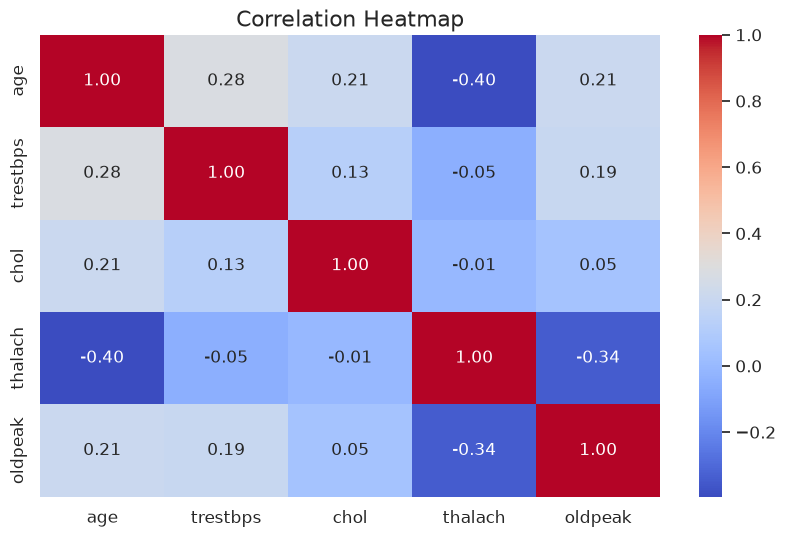

In [14]:
plt.title("Correlation Heatmap")
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)


Disini dapat terlihat korelasi antar fitur cukup rendah. Mari kita coba liat keterhubungannya dalam `pairwise plot`

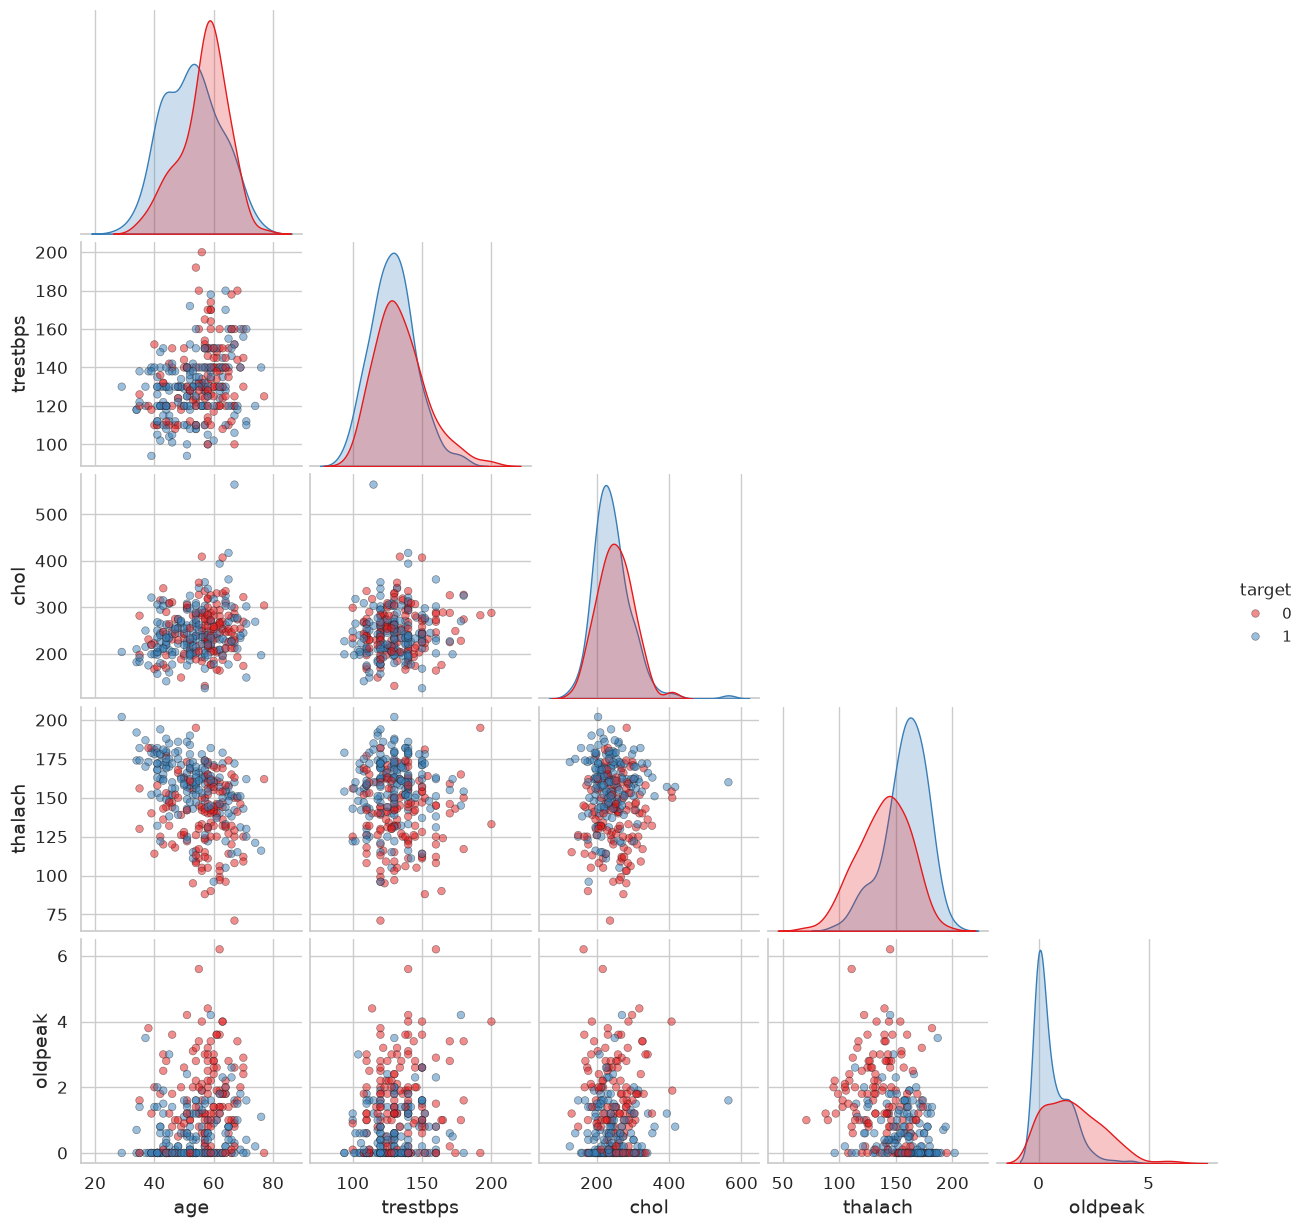

In [15]:
sns.pairplot(df, vars=num_cols, diag_kind="kde", corner=True, hue="target", palette="Set1", plot_kws={"alpha": 0.5, "s": 30, "edgecolor": "k"}, diag_kws={"shade": True})


Ya, kesimpulannya sama seperti yang ada di `correlation plot`. Hasilnya cenderung tidak membentuk pola secara linear

Untuk membuktikkan lebih lanjut, kami gunakan VIF (Variance Influence Factor) dalam melihat multikolinearitas

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

In [16]:
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

df_var = df[num_cols].dropna().copy()

X_centered = df_var - df_var.mean()

vif_data = pd.DataFrame({
    "feature": X_centered.columns,
    "VIF": [
        variance_inflation_factor(X_centered.values, i)
        for i in range(X_centered.shape[1])
    ]
})

print(
    vif_data.sort_values(
        "VIF",
        ascending=False
    )
)

    feature       VIF
0       age  1.345233
3   thalach  1.322545
4   oldpeak  1.176598
1  trestbps  1.131176
2      chol  1.057566


secara statistik memang terbukti apabila, tidak adanya multicorrelation plot

### Penanganan Multikolinearitas dengan PCA (High-VIF → PCA)

VIF mengukur seberapa besar varians koefisien regresi membengkak akibat korelasi antar prediktor:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

Aturan umum:
- `VIF < 5` → multikolinearitas rendah / dapat diabaikan
- `5 ≤ VIF < 10` → moderat, perlu perhatian
- `VIF ≥ 10` → serius, perlu penanganan (*drop* / regularisasi / PCA)

PCA (*Principal Component Analysis*) mengatasi multikolinearitas dengan mengubah fitur-fitur yang saling berkorelasi menjadi komponen baru yang **ortogonal (tidak berkorelasi)**:

$$
Z = X_{scaled} W
$$

di mana $W$ adalah matriks *eigenvector* dari matriks kovarians. Alur yang dipakai di sini:
1. Identifikasi fitur `high-VIF` (VIF ≥ threshold).
2. Standardisasi fitur tersebut (mean = 0, var = 1) karena PCA sensitif terhadap skala.
3. Fit PCA, pilih jumlah komponen berdasarkan *cumulative explained variance* (mis. ≥ 90%).
4. Ganti fitur asli yang berkorelasi dengan skor PC → **gabungkan** kembali ke dataframe.


Threshold VIF       : 5.0
Fitur high-VIF      : - (tidak ada, semua VIF < 5)
Fitur untuk PCA     : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Fitur dipertahankan : - (semua numerik masuk PCA)

 feature      VIF
     age 1.345233
 thalach 1.322545
 oldpeak 1.176598
trestbps 1.131176
    chol 1.057566


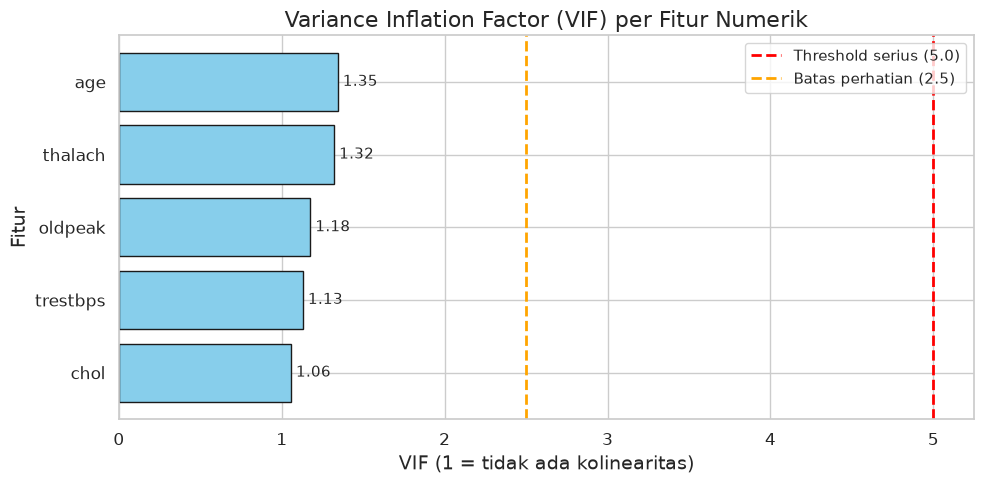

In [17]:
# --- Visualisasi VIF & identifikasi fitur High-VIF ---
VIF_THRESHOLD = 5.0  # standar; gunakan 2.5 bila ingin konservatif, 10 bila longgar

vif_sorted = vif_data.sort_values("VIF", ascending=True).reset_index(drop=True)
high_vif_features = vif_sorted.loc[vif_sorted["VIF"] >= VIF_THRESHOLD, "feature"].tolist()
# fallback: bila tidak ada yang >= threshold (kasus dataset ini), PCA didemokan ke semua fitur numerik
pca_features = high_vif_features if len(high_vif_features) >= 2 else num_cols
low_vif_features = [c for c in num_cols if c not in pca_features]

print(f"Threshold VIF       : {VIF_THRESHOLD}")
print(f"Fitur high-VIF      : {high_vif_features if high_vif_features else '- (tidak ada, semua VIF < 5)'}")
print(f"Fitur untuk PCA     : {pca_features}")
print(f"Fitur dipertahankan : {low_vif_features if low_vif_features else '- (semua numerik masuk PCA)'}")
print()
print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

colors = ["red" if v >= 5 else ("orange" if v >= 2.5 else "skyblue") for v in vif_sorted["VIF"]]

plt.figure(figsize=(10, 5))
plt.barh(vif_sorted["feature"], vif_sorted["VIF"], color=colors, edgecolor="k")
plt.axvline(VIF_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Threshold serius ({VIF_THRESHOLD})")
plt.axvline(2.5, color="orange", linestyle="--", linewidth=2, label="Batas perhatian (2.5)")
for i, v in enumerate(vif_sorted["VIF"]):
    plt.text(v + 0.03, i, f"{v:.2f}", va="center", fontsize=11)
plt.title("Variance Inflation Factor (VIF) per Fitur Numerik")
plt.xlabel("VIF (1 = tidak ada kolinearitas)")
plt.ylabel("Fitur")
plt.legend()
plt.tight_layout()
plt.show()


 PC  Explained (%)  Cumulative (%)
PC1          36.02           36.02
PC2          21.64           57.66
PC3          17.58           75.24
PC4          15.26           90.50
PC5           9.50          100.00
Komponen untuk ≥ 80% variance: 4 PC (aktual 90.50%)
Komponen untuk ≥ 90% variance: 4 PC (aktual 90.50%)
Komponen untuk ≥ 95% variance: 5 PC (aktual 100.00%)


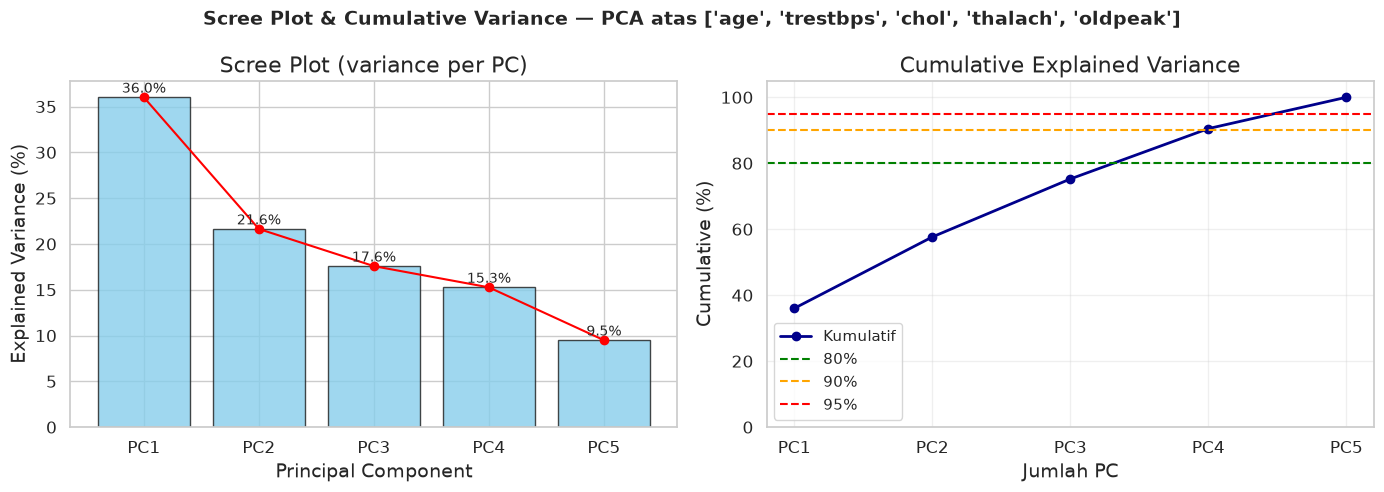

In [18]:
# --- PCA: Scree plot + Cumulative variance (1 figure gabungan) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled_pca = StandardScaler().fit_transform(df_var[pca_features])

pca_full = PCA(random_state=cfg.seed)
pca_full.fit(X_scaled_pca)

evr = pca_full.explained_variance_ratio_
cum_evr = evr.cumsum()
n_feat = len(pca_features)

evr_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_feat)],
    "Explained (%)": (evr * 100).round(2),
    "Cumulative (%)": (cum_evr * 100).round(2),
})
print(evr_table.to_string(index=False))
for t in [0.80, 0.90, 0.95]:
    k = int((cum_evr < t).sum() + 1)
    print(f"Komponen untuk ≥ {int(t*100)}% variance: {k} PC (aktual {cum_evr[k-1]*100:.2f}%)")

# Gabungan: kiri scree, kanan kumulatif
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Scree Plot & Cumulative Variance — PCA atas {pca_features}", fontsize=14, fontweight="bold")

x = np.arange(1, n_feat + 1)
ax[0].bar(x, evr * 100, color="skyblue", edgecolor="k", alpha=0.8)
ax[0].plot(x, evr * 100, color="red", marker="o")
for i, v in enumerate(evr * 100):
    ax[0].text(x[i], v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
ax[0].set_xticks(x)
ax[0].set_xticklabels([f"PC{i}" for i in x])
ax[0].set_title("Scree Plot (variance per PC)")
ax[0].set_xlabel("Principal Component")
ax[0].set_ylabel("Explained Variance (%)")

ax[1].plot(x, cum_evr * 100, color="darkblue", marker="o", linewidth=2, label="Kumulatif")
ax[1].axhline(80, color="green", linestyle="--", label="80%")
ax[1].axhline(90, color="orange", linestyle="--", label="90%")
ax[1].axhline(95, color="red", linestyle="--", label="95%")
ax[1].set_xticks(x)
ax[1].set_xticklabels([f"PC{i}" for i in x])
ax[1].set_title("Cumulative Explained Variance")
ax[1].set_xlabel("Jumlah PC")
ax[1].set_ylabel("Cumulative (%)")
ax[1].set_ylim(0, 105)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Loadings (eigenvector, kontribusi tiap fitur ke tiap PC):
            PC1    PC2    PC3    PC4    PC5
age       0.567  0.109 -0.182 -0.521  0.602
trestbps  0.382  0.420  0.735 -0.146 -0.341
chol      0.239  0.696 -0.529  0.383 -0.180
thalach  -0.505  0.481  0.311  0.164  0.625
oldpeak   0.469 -0.311  0.225  0.730  0.315


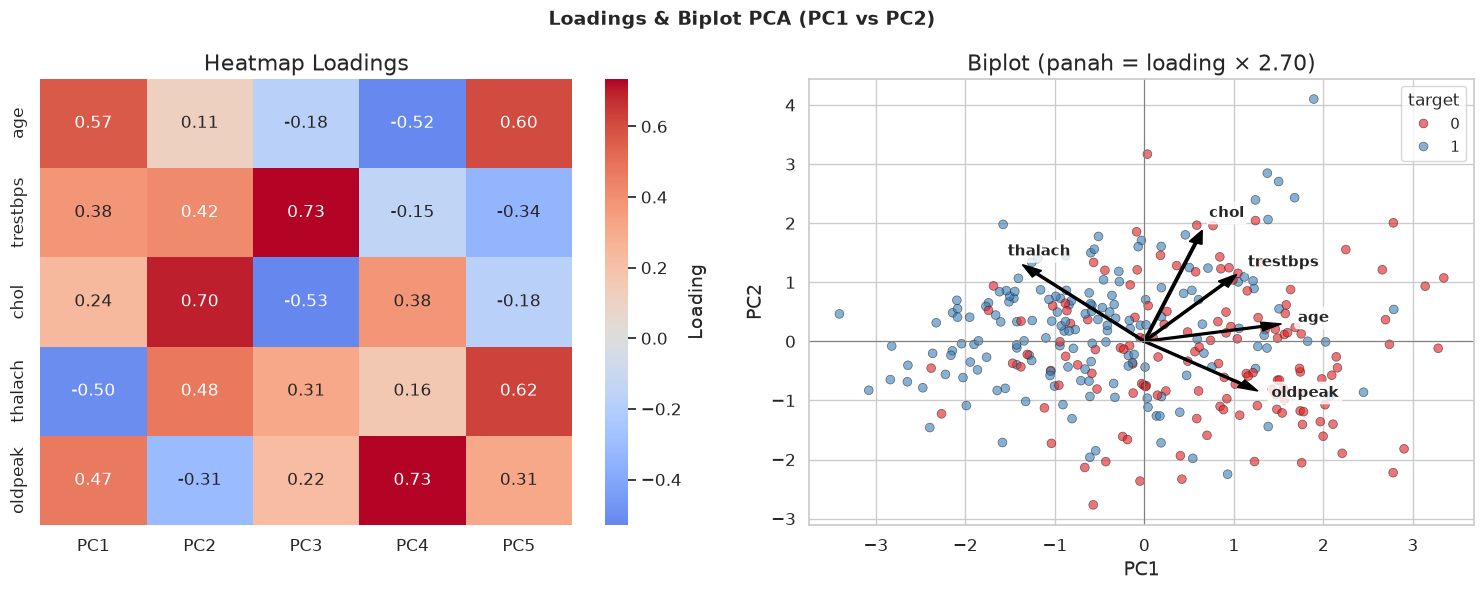

In [19]:
# --- Loadings + Biplot PC1-PC2 (1 figure gabungan) ---
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=pca_features,
    columns=[f"PC{i+1}" for i in range(n_feat)],
)
print("Loadings (eigenvector, kontribusi tiap fitur ke tiap PC):")
print(loadings.round(3).to_string())

# Skor 2 PC pertama untuk biplot
X_2d = pca_full.transform(X_scaled_pca)[:, :2]
pc_df = pd.DataFrame(X_2d, columns=["PC1", "PC2"], index=df_var.index)
pc_df["target"] = df.loc[df_var.index, cfg.target].astype(str).values

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Loadings & Biplot PCA (PC1 vs PC2)", fontsize=14, fontweight="bold")

# Kiri: heatmap loadings
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0], cbar_kws={"label": "Loading"})
ax[0].set_title("Heatmap Loadings")

# Kanan: biplot (scatter + vektor loadings)
sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="target", palette="Set1", alpha=0.6, edgecolor="k", s=40, ax=ax[1])
# vektor: skala agar proporsional dengan sebaran skor
scale = min(pc_df["PC1"].max() - pc_df["PC1"].min(), pc_df["PC2"].max() - pc_df["PC2"].min()) / 2.5
for feat in pca_features:
    vx, vy = loadings.loc[feat, "PC1"] * scale, loadings.loc[feat, "PC2"] * scale
    ax[1].arrow(0, 0, vx, vy, color="black", width=0.03, head_width=0.15, length_includes_head=True)
    ax[1].text(vx * 1.12, vy * 1.12, feat, fontsize=11, fontweight="bold",
               bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
ax[1].axhline(0, color="gray", linewidth=0.8)
ax[1].axvline(0, color="gray", linewidth=0.8)
ax[1].set_title(f"Biplot (panah = loading × {scale:.2f})")
ax[1].legend(title="target")

plt.tight_layout()
plt.show()


Komponen optimal (≥90% variance): 4 PC → 90.50% variance retained
Shape awal (df): (302, 14) | Shape gabungan (df_combined): (302, 13)
Kolom gabungan: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target', 'PC1', 'PC2', 'PC3', 'PC4']


,sex,cp,fbs,restecg,exang,slope,ca,thal,target,PC1,PC2,PC3,PC4
0,1,0,0,1,0,2,2,3,0,-0.879938,-0.252814,0.367231,0.044635
1,1,0,1,0,1,0,0,3,0,0.605352,-0.839228,1.298300,1.024627
2,1,0,0,1,1,0,0,3,0,2.107099,-1.401431,0.958744,-0.743537
3,1,0,0,1,0,2,1,3,0,-0.105677,0.406329,0.953619,-1.413248
4,0,0,1,1,0,1,3,2,0,2.144051,-0.261572,-0.796429,0.087523



VIF SESUDAH PCA (harus ≈ 1.0 = tidak berkorelasi):
feature  VIF
    PC1  1.0
    PC2  1.0
    PC3  1.0
    PC4  1.0


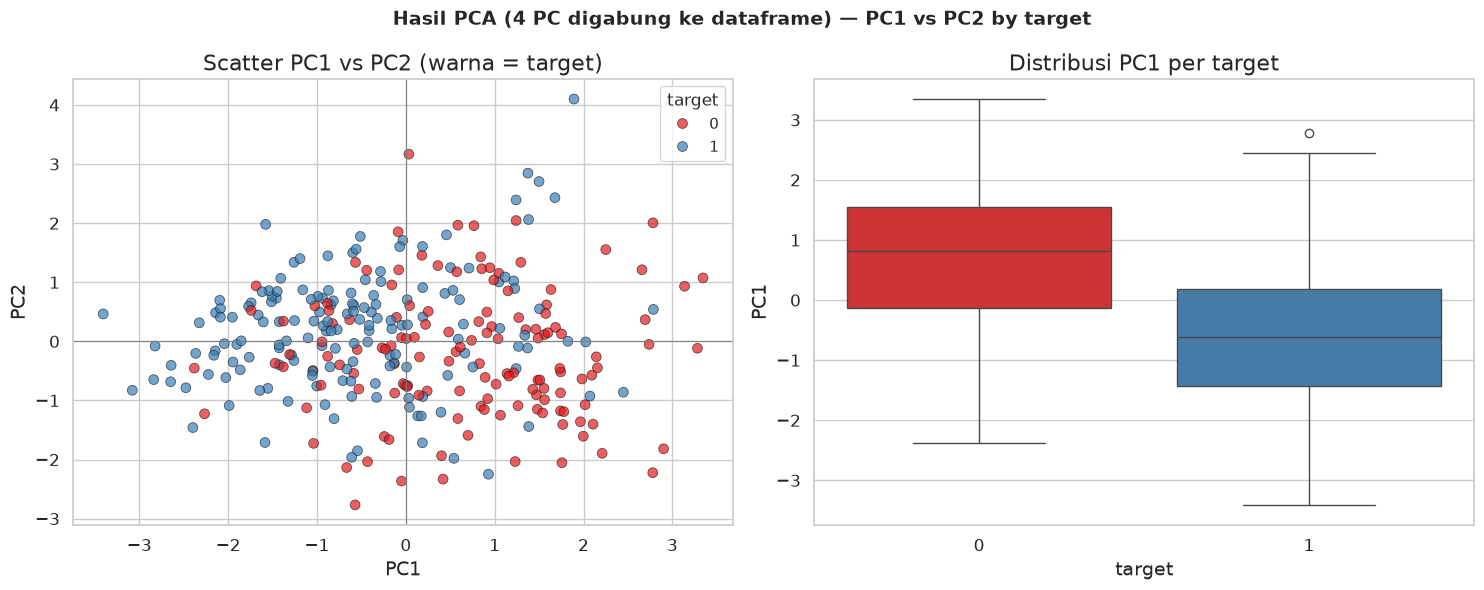


Korelasi antar-PC (harus ≈ 0):
     PC1  PC2  PC3  PC4
PC1  1.0  0.0  0.0 -0.0
PC2  0.0  1.0 -0.0 -0.0
PC3  0.0 -0.0  1.0  0.0
PC4 -0.0 -0.0  0.0  1.0


In [20]:
# --- Transform PCA + Gabungkan (merge) ke dataframe + validasi VIF ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Pilih k agar kumulatif ≥ 90%
cum_evr = pca_full.explained_variance_ratio_.cumsum()
n_opt = int((cum_evr < 0.90).sum() + 1)
n_opt = max(2, min(n_opt, len(pca_features)))  # minimal 2 agar bisa divisualkan
print(f"Komponen optimal (≥90% variance): {n_opt} PC → {cum_evr[n_opt-1]*100:.2f}% variance retained")

pca_opt = PCA(n_components=n_opt, random_state=cfg.seed)
X_pca_opt = pca_opt.fit_transform(X_scaled_pca)
pc_cols = [f"PC{i+1}" for i in range(n_opt)]
df_pca = pd.DataFrame(X_pca_opt, columns=pc_cols, index=df_var.index)

# GABUNGKAN: buang fitur PCA-asli, tempel skor PC + sisa kolom (kategorikal + low-VIF numerik + target)
df_combined = pd.concat(
    [df.loc[df_var.index].drop(columns=pca_features), df_pca],
    axis=1,
)
print(f"Shape awal (df): {df.shape} | Shape gabungan (df_combined): {df_combined.shape}")
print(f"Kolom gabungan: {df_combined.columns.tolist()}")
display(df_combined.head())

# Bukti multikolinearitas hilang: VIF sesudah PCA ≈ 1.0 (ortogonal)
Xc_after = df_pca - df_pca.mean()
vif_after = pd.DataFrame({
    "feature": df_pca.columns,
    "VIF": [variance_inflation_factor(Xc_after.values, i) for i in range(df_pca.shape[1])],
})
print("\nVIF SESUDAH PCA (harus ≈ 1.0 = tidak berkorelasi):")
print(vif_after.to_string(index=False))

# GABUNGAN GRAFIS: kiri scatter PC1-PC2 by target, kanan distribusi PC per target
df_plot_pca = df_pca.copy()
df_plot_pca["target"] = df.loc[df_var.index, cfg.target].astype(str).values

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Hasil PCA ({n_opt} PC digabung ke dataframe) — PC1 vs PC2 by target", fontsize=14, fontweight="bold")

sns.scatterplot(data=df_plot_pca, x="PC1", y="PC2", hue="target", palette="Set1",
                alpha=0.7, edgecolor="k", s=50, ax=ax[0])
ax[0].axhline(0, color="gray", linewidth=0.8)
ax[0].axvline(0, color="gray", linewidth=0.8)
ax[0].set_title("Scatter PC1 vs PC2 (warna = target)")

# Boxplot PC1 per target untuk melihat daya pisah
sns.boxplot(data=df_plot_pca, x="target", y="PC1", hue="target", palette="Set1", legend=False, ax=ax[1])
ax[1].set_title("Distribusi PC1 per target")
ax[1].set_xlabel("target")

plt.tight_layout()
plt.show()

# Korelasi antar-PC (harus ≈ 0 = gabungan bersih)
print("\nKorelasi antar-PC (harus ≈ 0):")
print(df_pca.corr().round(3).to_string())


**Interpretasi & apa yang digabungkan:**

- **VIF:** semua fitur numerik (`age`, `thalach`, `oldpeak`, `trestbps`, `chol`) memiliki VIF 1,06–1,35 (< 5), artinya **tidak ada multikolinearitas serius**. Karena itu `high_vif_features` kosong dan — sebagai demonstrasi prosedur — PCA dijalankan pada seluruh `num_cols`. Jika suatu saat ada fitur dengan VIF ≥ 5, kode di atas otomatis hanya mem-PCA-kan subset tersebut (`pca_features = high_vif_features`) dan mempertahankan sisanya (`low_vif_features`).
- **Scree / kumulatif:** PC1 ≈ 36%, PC2 ≈ 21,6%, PC1–PC2 ≈ 57,7%, butuh **4 PC untuk ≥ 90%** variance (90,50%). Artinya reduksi 5 → 4 dimensi hampir tanpa kehilangan informasi; reduksi ke 2D (57,7%) cocok untuk visualisasi tetapi membuang ~42% variance.
- **Loadings / biplot:** `age` (+) vs `thalach` (−) mendominasi PC1 berlawanan arah — konsisten dengan korelasi negatif usia vs denyut maksimum; `chol`/`trestbps` kuat di PC2; `oldpeak` kuat di PC1/PC4. Panah yang searah = berkorelasi positif, berlawanan = negatif, tegak lurus = tidak berkorelasi.
- **Gabungan (`df_combined`):** kolom `pca_features` yang berkorelasi **diganti** dengan `PC1..PC4` yang ortogonal, lalu digabung (`concat`) dengan kolom kategorikal + `target`. Bentuk akhir `(302, 13)`: 9 kolom kategorikal/target + 4 PC. Validasi: **VIF sesudah PCA = 1,0** untuk semua PC dan korelasi antar-PC ≈ 0 — multikolinearitas (bahkan yang ringan) terbukti hilang.
- **Scatter PC1–PC2:** pewarnaan `target` menunjukkan separasi parsial (konsisten dengan temuan UMAP), dan boxplot PC1 per target memperlihatkan pergeseran distribusi — sehingga `df_combined` siap dipakai sebagai input *clustering / modeling* yang bebas multikolinearitas tanpa mengubah `df` asli (analisis setelah ini tetap memakai `df`).


### Dimensionality Reduction

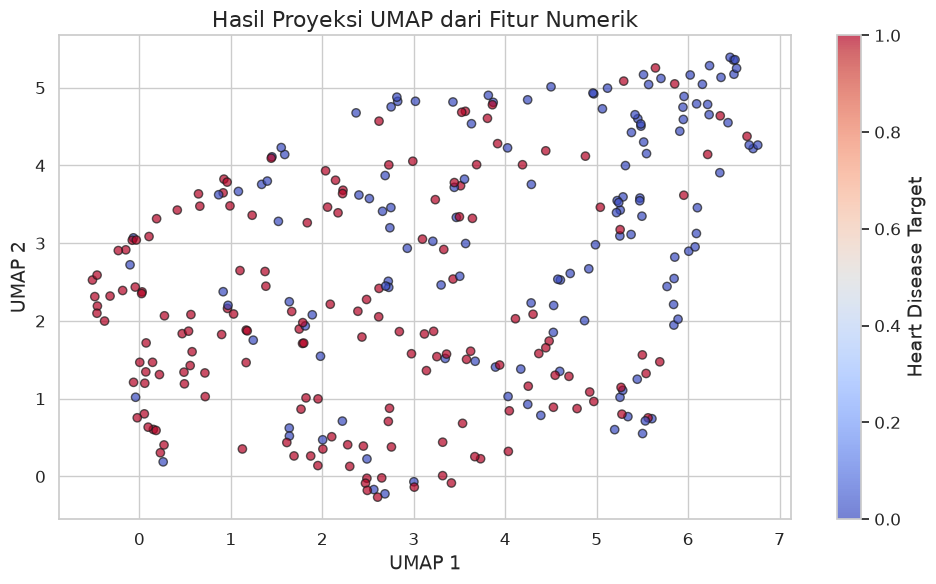

In [21]:
from umap import UMAP
from sklearn.preprocessing import StandardScaler

model = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=cfg.seed
)

df_umap = df[num_cols].copy()
df_umap = StandardScaler().fit_transform(df_umap)
df_umap_transformed = model.fit_transform(df_umap)

plt.figure(figsize=(10, 6))
plt.scatter(
    df_umap_transformed[:, 0],
    df_umap_transformed[:, 1],
    c=df[cfg.target],
    cmap="coolwarm",
    alpha=0.7,
    edgecolor="k"
)
plt.title("Hasil Proyeksi UMAP dari Fitur Numerik")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Heart Disease Target")
plt.tight_layout()

Sebenarnya disini terlihat sedikit pola, dimana target `1` cenderung untuk mayoritas berada di nilai yang cukup besar dibandingkan dengan `0`

### Clustering

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

cluster_df = df[cluster_cols + ["target"]].dropna().copy()

X_scaled = StandardScaler().fit_transform(
    cluster_df[cluster_cols]
)

scores = {}

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

scores


{2: 0.23989795693671803,
 3: 0.2260309776081752,
 4: 0.20079370452967676,
 5: 0.20542241714576828,
 6: 0.19798303986963575}

In [23]:
best_k = max(scores, key=scores.get)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    cluster_df
    .groupby("cluster")[cluster_cols + ["target"]]
    .mean()
)

cluster_profile

,age,trestbps,chol,thalach,oldpeak,target
cluster,,,,,,
0,60.891473,139.434109,261.658915,133.612403,1.748837,0.310078
1,49.595376,125.763006,235.196532,161.468208,0.516763,0.716763


| Fitur              | Cluster 0 | Cluster 1 | Interpretasi perbedaan                                            |
| ------------------ | --------: | --------: | ----------------------------------------------------------------- |
| `age`              |     60,89 |     49,60 | Cluster 0 rata-rata lebih tua sekitar 11,30 tahun                 |
| `trestbps`         |    139,43 |    125,76 | Cluster 0 memiliki tekanan darah istirahat rata-rata lebih tinggi |
| `chol`             |    261,66 |    235,20 | Cluster 0 memiliki total kolesterol rata-rata lebih tinggi        |
| `thalach`          |    133,61 |    161,47 | Cluster 1 mencapai denyut jantung maksimum rata-rata lebih tinggi |
| `oldpeak`          |      1,75 |      0,52 | Cluster 0 memiliki depresi ST rata-rata lebih tinggi              |
| Rata-rata `target` |     0,310 |     0,717 | Proporsi `target = 1` lebih tinggi pada Cluster 1                 |


### Cramer's V Heatmap

Asosiasi antar kategorikal feature

In [24]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(
        confusion_matrix,
        correction=False
    )[0]

    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    # Bias correction
    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )

    if denominator <= 0:
        return 0.0

    return np.sqrt(
        phi2_corrected / denominator
    )

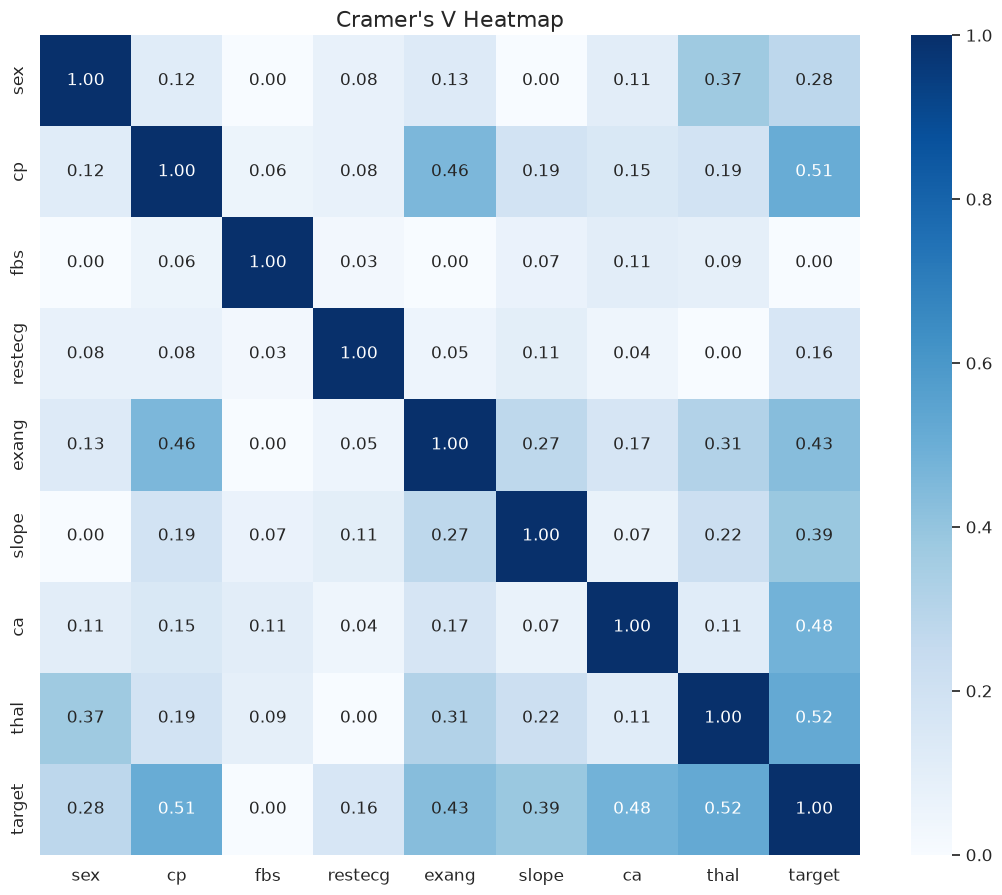

In [25]:
categorical_analysis_cols = cat_cols

cramers_matrix = pd.DataFrame(
    index=categorical_analysis_cols,
    columns=categorical_analysis_cols,
    dtype=float
)

for col_1 in categorical_analysis_cols:
    for col_2 in categorical_analysis_cols:
        cramers_matrix.loc[col_1, col_2] = cramers_v(
            df[col_1],
            df[col_2]
        )

plt.figure(figsize=(11, 9))

sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True
)

plt.title("Cramer's V Heatmap")
plt.tight_layout()
plt.show()

Disini secara tidak langsung mengatakan apabila, `thal` dan `cp` cukup berkorelasi dalam menentukan `target`

### Proportional Table

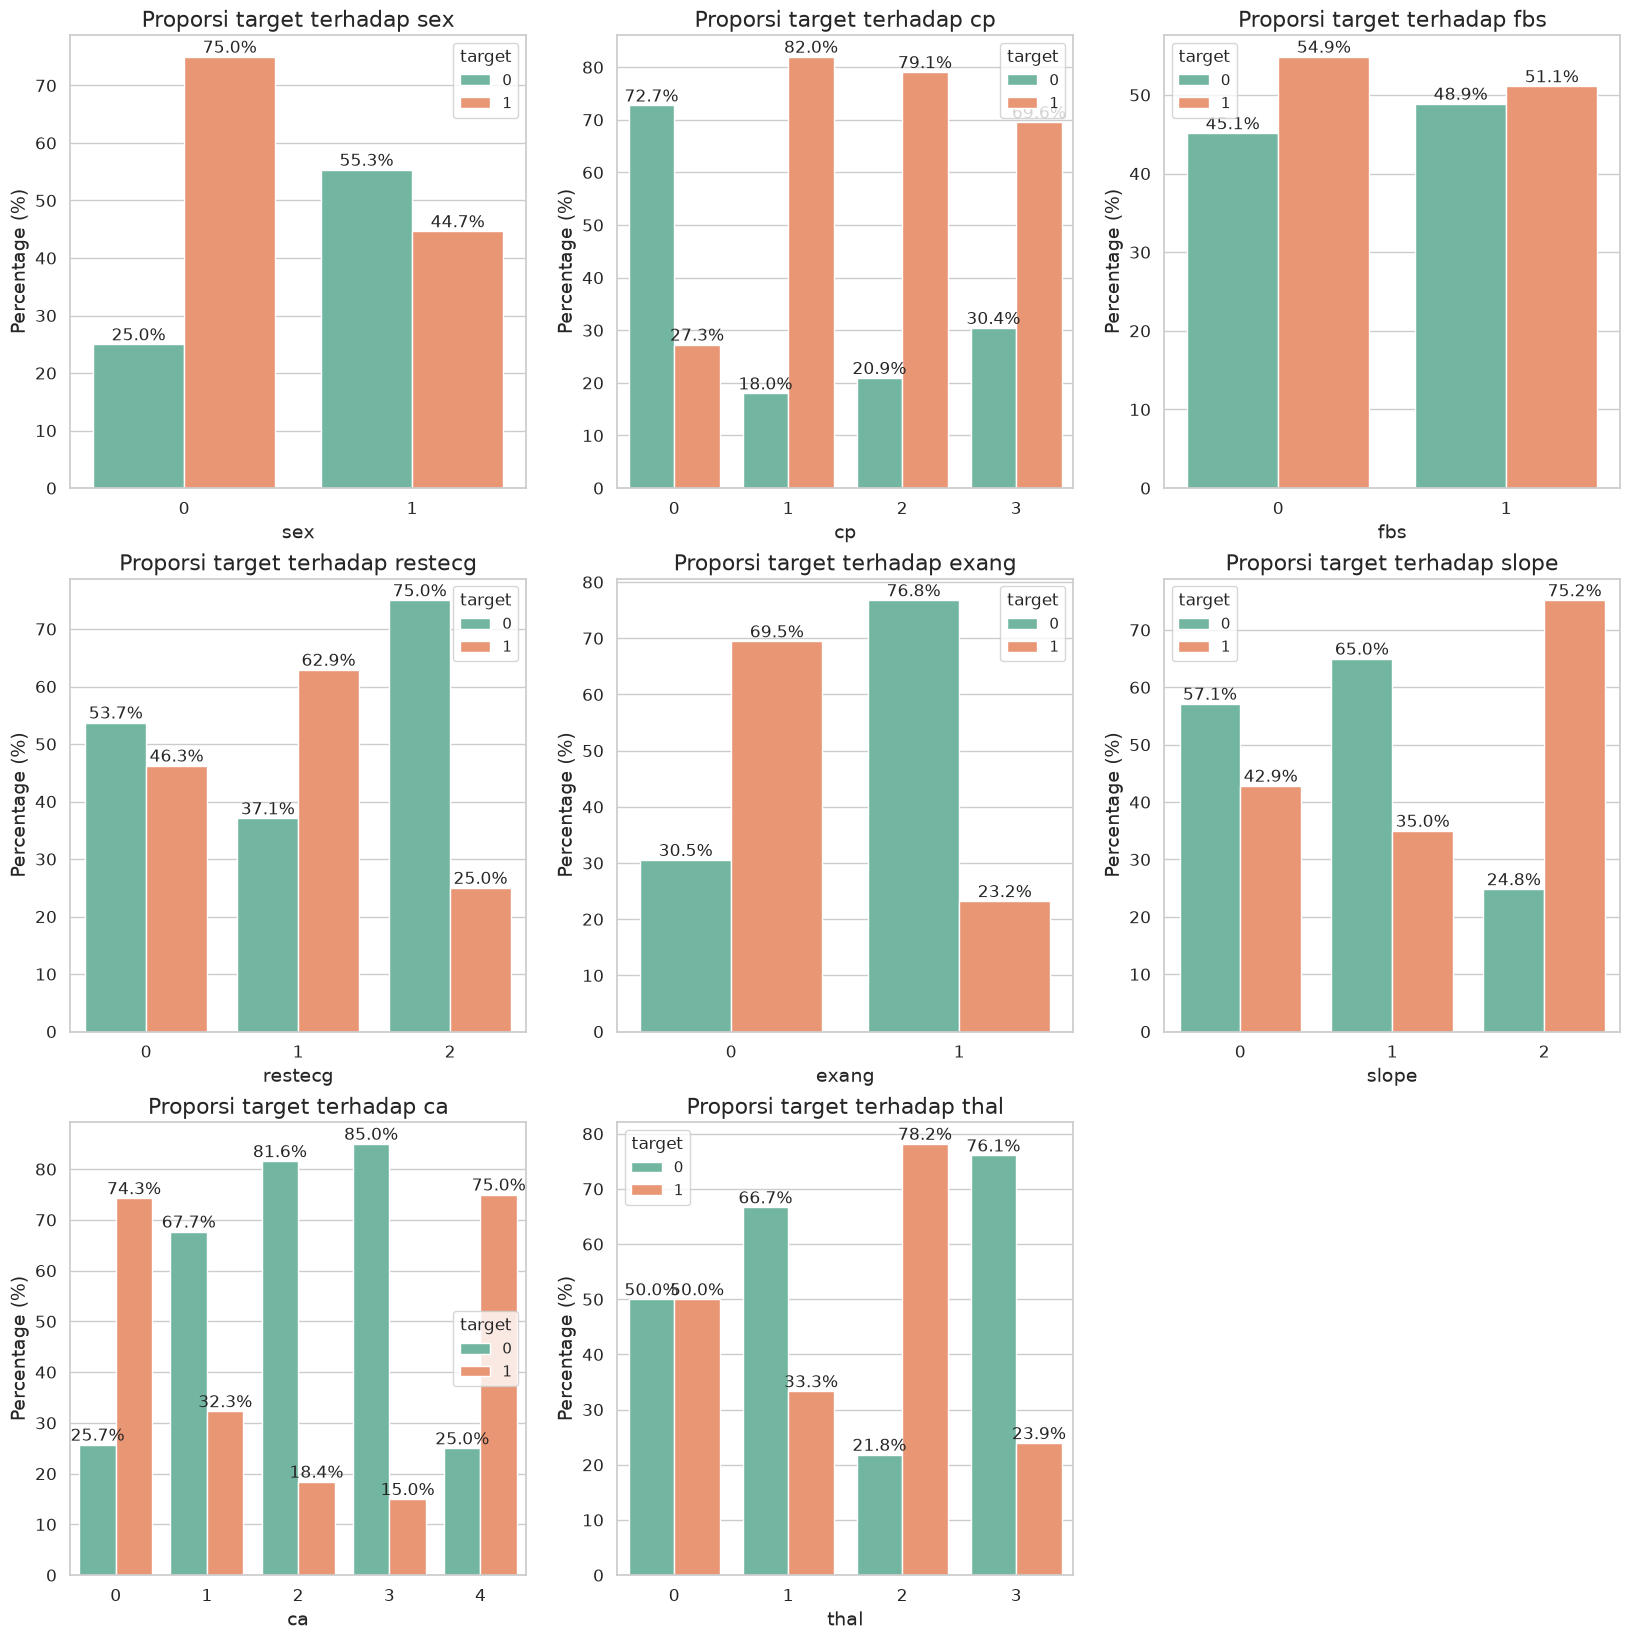

In [26]:
fig,ax = plt.subplots(3,3,figsize=(20, 20))
ax = ax.flatten()

for i, col in enumerate(cat_cols):
    if col == "target":
        continue
    target_prop = (
        pd.crosstab(
            df[col],
            df["target"],
            normalize="index"
        )
        .mul(100)
        .reset_index()
        .melt(
            id_vars=col,
            var_name="target",
            value_name="percentage"
        )
    )
    sns.barplot(
        data=target_prop,
        x=col,
        y="percentage",
        hue="target",
        palette="Set2",
        ax=ax[i]
    )

    for container in ax[i].containers:
        ax[i].bar_label(
            container,
            fmt="%.1f%%"
        )
    
    ax[i].set_title(f"Proporsi target terhadap {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Percentage (%)")

for a in ax[len(cat_cols)-1:]:
    a.remove()


### Multiple Correspondence Analysis (MCA)

In [27]:
import prince

mca_df = df[cat_cols].copy()

for col in mca_df.columns:
    mca_df[col] = (
        col + "_" + mca_df[col].astype(str)
    )

X_mca = mca_df[cat_cols]

mca = prince.MCA(
    n_components=2,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42
)

mca = mca.fit(X_mca)

coordinates = mca.row_coordinates(X_mca)

mca_result = coordinates.copy()
mca_result.columns = ["Dimension 1", "Dimension 2"]
mca_result["target"] = df.loc[
    X_mca.index,
    "target"
].astype(str).values

ModuleNotFoundError: No module named 'prince'

In [28]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=mca_result,
    x="Dimension 1",
    y="Dimension 2",
    hue="target",
    alpha=0.55,
    palette="Set1"
)

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

plt.title("Projeksi MCA fitur Kategoris")
plt.tight_layout()
plt.show()

NameError: name 'mca_result' is not defined

<Figure size 1000x700 with 0 Axes>

# Anomaly Scoring

In [29]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

# Ambil fitur prediktor saja
X = (
    df[num_cols]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

isolation_forest = IsolationForest(
    n_estimators=500,
    max_samples="auto",
    contamination=0.05,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

anomaly_label = isolation_forest.fit_predict(X_scaled)
raw_score = isolation_forest.score_samples(X_scaled)
anomaly_score = -raw_score

# Simpan hasil ke indeks yang sesuai
df.loc[X.index, "anomaly_label"] = anomaly_label
df.loc[X.index, "anomaly_score"] = anomaly_score

# Ubah label menjadi lebih mudah dibaca
df["anomaly_status"] = df["anomaly_label"].map({
    1: "Normal",
    -1: "Anomali"
})

In [30]:
anomaly_summary = (
    df["anomaly_status"]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

anomaly_summary["percentage"] = (
    anomaly_summary["count"]
    / anomaly_summary["count"].sum()
    * 100
)

anomaly_summary.round(2)

,count,percentage
anomaly_status,,
Normal,286,94.7
Anomali,16,5.3


In [31]:
anomalies = (
    df[df["anomaly_label"] == -1]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)

anomalies[
    num_cols
    + ["target", "anomaly_score"]
].head(20)

,age,trestbps,chol,thalach,oldpeak,target,anomaly_score
69,62,160,164,145,6.2,0,0.634275
158,67,115,564,160,1.6,1,0.616388
151,54,192,283,195,0.0,0,0.604322
175,56,200,288,133,4.0,0,0.597950
54,55,140,217,111,5.6,0,0.586063
60,29,130,204,202,0.0,1,0.580229
450,63,150,407,154,4.0,0,0.576523
29,55,180,327,117,3.4,0,0.569144
332,37,130,250,187,3.5,1,0.560455
258,38,120,231,182,3.8,0,0.559308


In [32]:
profile_summary = (
    df.dropna(subset=["anomaly_status"])
    .groupby("anomaly_status")
    .agg(
        n=("anomaly_status", "size"),
        age_median=("age", "median"),
        trestbps_median=("trestbps", "median"),
        chol_median=("chol", "median"),
        thalach_median=("thalach", "median"),
        oldpeak_median=("oldpeak", "median"),
        target_1_proportion=("target", "mean")
    )
)

profile_summary["target_1_percentage"] = (
    profile_summary["target_1_proportion"] * 100
)

profile_summary.round(2)

,n,age_median,trestbps_median,chol_median,thalach_median,oldpeak_median,target_1_proportion,target_1_percentage
anomaly_status,,,,,,,,
Anomali,16,58.5,140.0,243.5,142.5,3.45,0.375,37.5
Normal,286,55.0,130.0,240.5,153.0,0.60,0.552448,55.244755


In [33]:
feature_deviation = pd.DataFrame(
    X_scaled,
    columns=num_cols,
    index=X.index
).abs()

feature_deviation["dominant_feature"] = (
    feature_deviation.idxmax(axis=1)
)

feature_deviation["maximum_deviation"] = (
    feature_deviation[num_cols].max(axis=1)
)

df.loc[
    feature_deviation.index,
    "dominant_anomalous_feature"
] = feature_deviation["dominant_feature"]

anomalies = (
    df[df["anomaly_label"] == -1]
    .sort_values("anomaly_score", ascending=False)
)

anomalies[
    num_cols
    + [
        "anomaly_score",
        "dominant_anomalous_feature"
    ]
].head(20)

,age,trestbps,chol,thalach,oldpeak,anomaly_score,dominant_anomalous_feature
69,62,160,164,145,6.2,0.634275,oldpeak
158,67,115,564,160,1.6,0.616388,chol
151,54,192,283,195,0.0,0.604322,trestbps
175,56,200,288,133,4.0,0.597950,trestbps
54,55,140,217,111,5.6,0.586063,oldpeak
60,29,130,204,202,0.0,0.580229,age
450,63,150,407,154,4.0,0.576523,chol
29,55,180,327,117,3.4,0.569144,trestbps
332,37,130,250,187,3.5,0.560455,oldpeak
258,38,120,231,182,3.8,0.559308,oldpeak


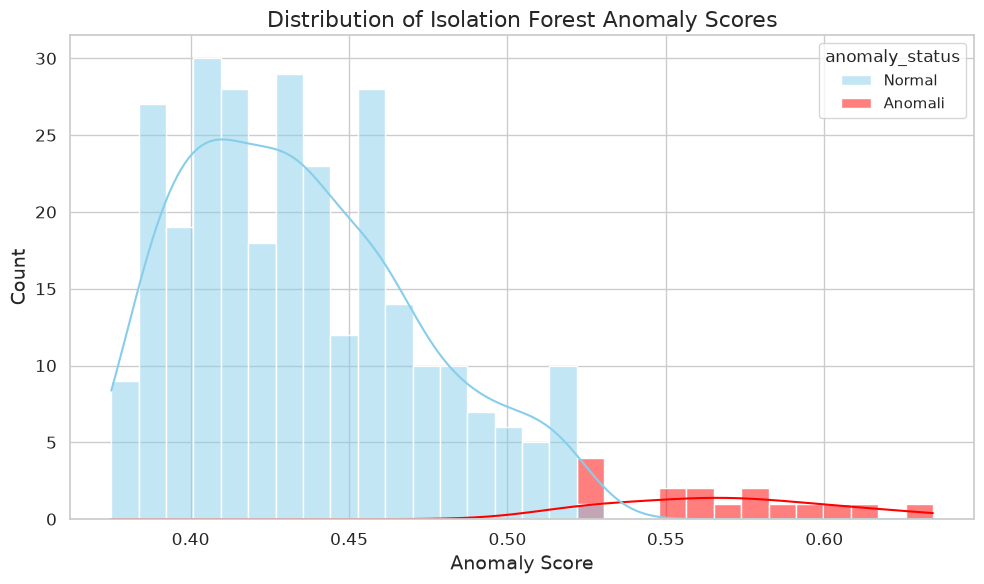

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df.dropna(subset=["anomaly_score"]),
    x="anomaly_score",
    hue="anomaly_status",
    bins=30,
    kde=True,
    palette={
        "Normal": "skyblue",
        "Anomali": "red"
    }
)

plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

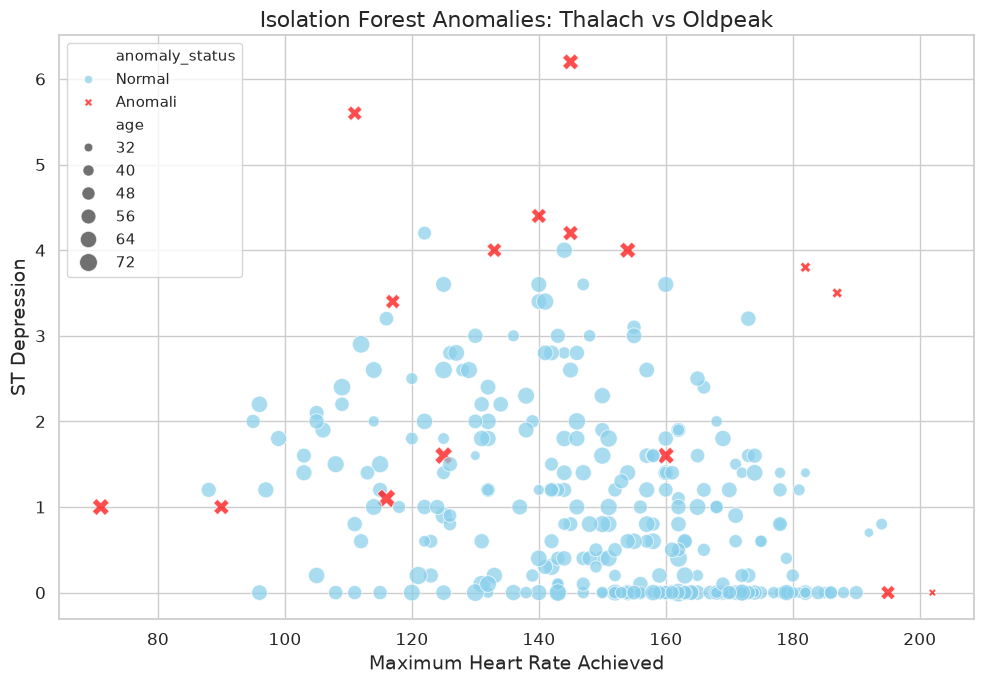

In [35]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df.dropna(subset=["anomaly_status"]),
    x="thalach",
    y="oldpeak",
    hue="anomaly_status",
    style="anomaly_status",
    size="age",
    sizes=(30, 180),
    alpha=0.7,
    palette={
        "Normal": "skyblue",
        "Anomali": "red"
    }
)

plt.title("Isolation Forest Anomalies: Thalach vs Oldpeak")
plt.xlabel("Maximum Heart Rate Achieved")
plt.ylabel("ST Depression")
plt.tight_layout()
plt.show()

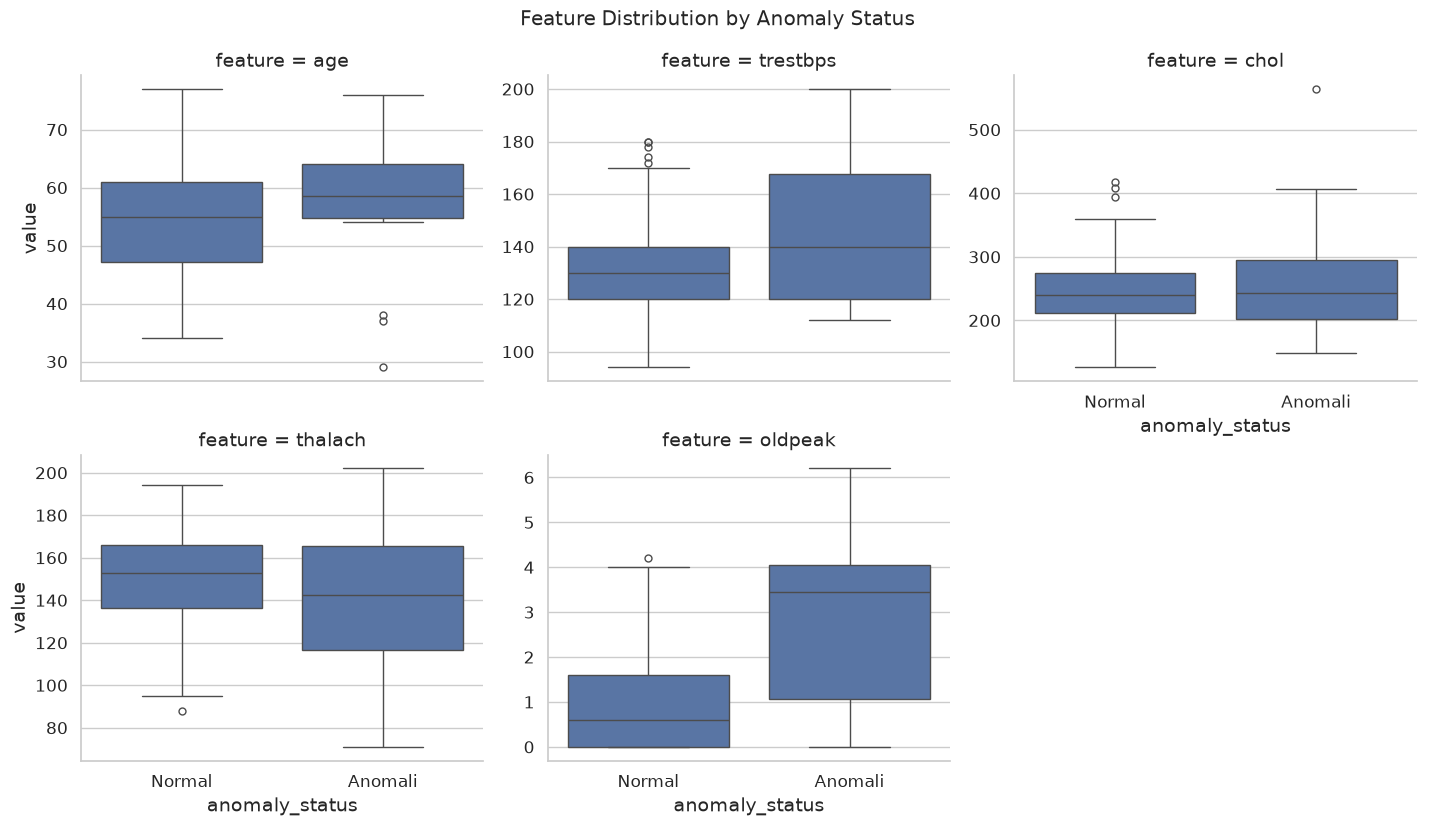

In [36]:
plot_df = df.melt(
    id_vars="anomaly_status",
    value_vars=num_cols,
    var_name="feature",
    value_name="value"
)

g = sns.catplot(
    data=plot_df,
    x="anomaly_status",
    y="value",
    col="feature",
    kind="box",
    col_wrap=3,
    sharey=False,
    height=4,
    aspect=1.2
)

g.fig.suptitle(
    "Feature Distribution by Anomaly Status",
    y=1.03
)

plt.show()